# 06 · Hypothesentest — Favorita

## 0 · Imports & Setup

In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import os
import sys

sys.path.append(os.path.abspath('../03_src'))

from utilis import mape, rmse, compute_metrics, load_preds
from config import (
    PROCESSED, FINAL, TARGET_COL, FEATURE_COLS,
    EXOG_COLS, STAT_EXOG, HIST_EXOG,
    TRAIN_END, VAL_END, LOOKBACK, HORIZON,
    MODELL_ORDER, MODELL_COLORS, PRED_COLS, RESULTS, FILE_NAMES
)

sns.set_style('whitegrid')


## 1 - Daten laden

In [3]:
df = pl.read_parquet(FINAL / 'final_dataset.parquet')

train     = df.filter(pl.col('date') <= TRAIN_END)
val       = df.filter((pl.col('date') > TRAIN_END) & (pl.col('date') <= VAL_END))
test      = df.filter(pl.col('date') > VAL_END)
train_val = df.filter(pl.col('date') <= VAL_END)

stores = sorted(df['store_nbr'].unique().to_list())

print(f'Train:     {train.shape}  {train["date"].min()} → {train["date"].max()}')
print(f'Val:       {val.shape}    {val["date"].min()} → {val["date"].max()}')
print(f'Test:      {test.shape}   {test["date"].min()} → {test["date"].max()}')
print(f'Stores:    {len(stores)}')

Train:     (70114, 37)  2013-01-29 → 2016-12-31
Val:       (7965, 37)    2017-01-01 → 2017-05-31
Test:      (4104, 37)   2017-06-01 → 2017-08-15
Stores:    54


## 2 · Ausgangsdatensatz

In [4]:
models_cfg = {
    'XGBoost':  'pred_xgb',
    'LightGBM': 'pred_lgbm',
    'PatchTST': 'pred_patchtst',
    'NHITS':    'pred_nhits',
    'SARIMAX':  'pred_sarimax',
    'Prophet':  'pred_prophet',
}
models_cfg

{'XGBoost': 'pred_xgb',
 'LightGBM': 'pred_lgbm',
 'PatchTST': 'pred_patchtst',
 'NHITS': 'pred_nhits',
 'SARIMAX': 'pred_sarimax',
 'Prophet': 'pred_prophet'}

In [5]:
base = (
    test.select(['store_nbr', 'date', TARGET_COL])
    .rename({TARGET_COL: 'y_true'})
    .to_pandas()
)


In [6]:
for name, col in models_cfg.items():
    fname = f'test_{name.lower()}.parquet'
    try:
        pred_df = pl.read_parquet(RESULTS / fname).to_pandas()
        base = base.merge(pred_df[['store_nbr', 'date', col]],
                          on=['store_nbr', 'date'], how='left')
    except FileNotFoundError:
        print(f'Nicht gefunden: {fname}')

In [7]:

stores_pd = pl.read_parquet(PROCESSED / 'stores.parquet').to_pandas()
base = base.merge(stores_pd[['store_nbr', 'type', 'cluster']],
                  on='store_nbr', how='left')
base

,store_nbr,date,y_true,pred_xgb,pred_lgbm,pred_patchtst,pred_nhits,pred_sarimax,pred_prophet,type,cluster
0,1,2017-06-01,1815,1816.982300,1809.406816,1660.943970,1671.510742,1602.027703,1685.763841,D,13
1,1,2017-06-02,1925,1979.134888,1919.192006,1565.402954,1618.768677,1454.307586,1702.832804,D,13
2,1,2017-06-03,1420,1426.523315,1406.175371,1360.430908,1562.789307,1240.680557,1246.257371,D,13
3,1,2017-06-04,525,525.163391,532.730107,474.035034,1319.485718,545.854603,459.782668,D,13
4,1,2017-06-05,1883,1881.178955,1892.467546,1192.562134,1697.511353,1669.458555,1676.592816,D,13
...,...,...,...,...,...,...,...,...,...,...,...
4099,54,2017-08-11,768,770.002380,774.441403,843.519897,1286.097900,771.595969,754.592989,C,3
4100,54,2017-08-12,903,896.292053,901.082840,868.788513,1402.123169,946.317499,932.948913,C,3
4101,54,2017-08-13,1054,1054.234619,1053.828172,1003.213318,1400.005615,1084.098506,1100.898020,C,3
4102,54,2017-08-14,818,819.478394,817.904740,946.838257,1308.153076,822.844112,822.234089,C,3


In [8]:
store_metrics = []
for store_id, grp in base.groupby('store_nbr'):
    for model_name, col in models_cfg.items():
        if col not in grp.columns or grp[col].isna().all():
            continue
        mask   = grp[col].notna() & grp['y_true'].notna()
        y_true = grp.loc[mask, 'y_true'].values
        y_pred = grp.loc[mask, col].values
        store_metrics.append({
            'store_nbr':  store_id,
            'model':      model_name,
            'store_type': grp['type'].iloc[0],
            'MAE':        mean_absolute_error(y_true, y_pred),
            'RMSE':       rmse(y_true, y_pred),
            'MAPE':       mape(y_true, y_pred),
            'std_true':   y_true.std(),
            'acf_lag7':   pd.Series(y_true).autocorr(lag=7),
            'acf_lag14':   pd.Series(y_true).autocorr(lag=14),

        })

metrics_df = pd.DataFrame(store_metrics)

# ── Gesamtübersicht ───────────────────────────────────────
summary = metrics_df.groupby('model')[['MAE', 'RMSE', 'MAPE']].mean().round(2)
print(summary.sort_values('MAE'))

             MAE    RMSE   MAPE
model                          
XGBoost     6.27    8.59   0.35
LightGBM    9.47   12.23   0.57
PatchTST  101.19  128.90   6.77
SARIMAX   105.96  135.87   6.71
Prophet   248.39  300.35  12.93
NHITS     285.43  316.48  21.03


C:\Users\maxkr\AppData\Local\Temp\ipykernel_21472\2925250569.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\maxkr\AppData\Local\Temp\ipykernel_21472\2925250569.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\maxkr\AppData\Local\Temp\ipykernel_21472\2925250569.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


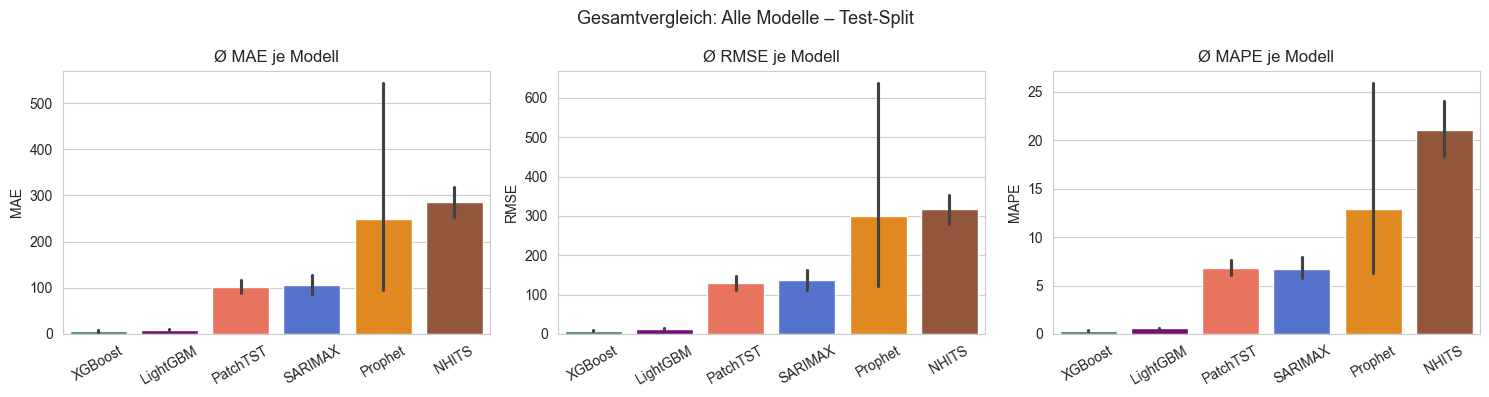

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
order = summary.sort_values('MAE').index.tolist()
for i, metric in enumerate(['MAE', 'RMSE', 'MAPE']):
    sns.barplot(
        data=metrics_df, x='model', y=metric,
        order=order,
        palette=MODELL_COLORS,
        ax=axes[i]
    )
    axes[i].set_title(f'Ø {metric} je Modell', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
plt.suptitle('Gesamtvergleich: Alle Modelle – Test-Split', fontsize=13)
plt.tight_layout()
plt.show()

### H1: Wenn keine filialspezifische Normalisierung angewendet wird, dann erzielen Gradient-Boosting-Verfahren bei rechtsschiefen Transaktionsdaten mit Extremwerten eine höhere Prognosegenauigkeit als Deep-Learning-Architekturen.
Metrik: MAE (absoluter Fehler) und RMSE (bestraft Extremwerte
Überproportional → direkt relevant für Rechtsschiefen-Hypothese)
Bestätigt wenn: MAE/RMSE von XGBoost oder LightGBM < PatchTST und NHITS

Prophet udn SARIMAX als Vergleichsmodell

C:\Users\maxkr\AppData\Local\Temp\ipykernel_21472\1111545110.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\maxkr\AppData\Local\Temp\ipykernel_21472\1111545110.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


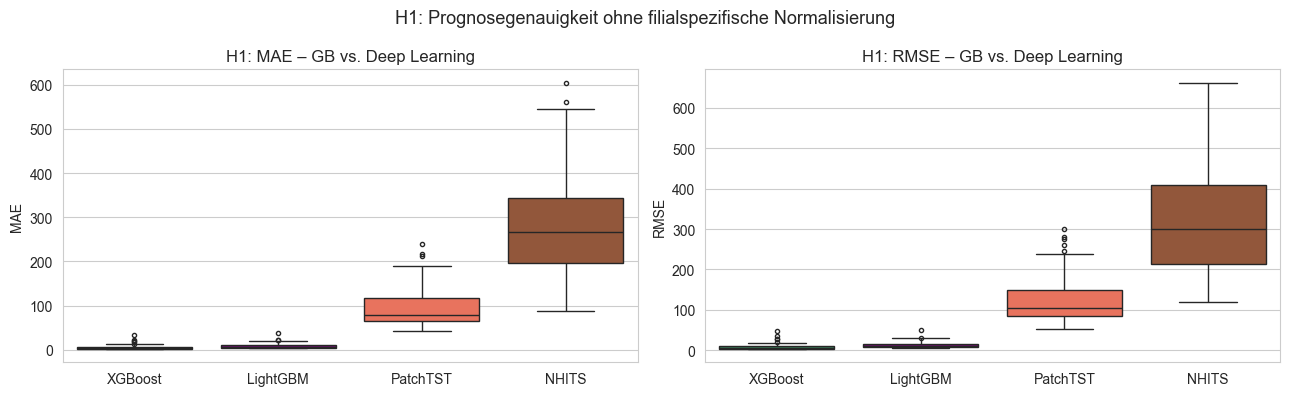

In [20]:

h1_models = ['XGBoost', 'LightGBM', 'PatchTST', 'NHITS']
h1_df     = metrics_df[metrics_df['model'].isin(h1_models)]
h1_summary = h1_df.groupby('model')[['MAE', 'RMSE']].mean().round(1).sort_values('MAE')


fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for i, metric in enumerate(['MAE', 'RMSE']):
    sns.boxplot(
        data=h1_df, x='model', y=metric,
        order=h1_models,
        palette=MODELL_COLORS,
        flierprops={'markersize': 3}, ax=axes[i]
    )
    axes[i].set_title(f'H1: {metric} – GB vs. Deep Learning', fontsize=12)
    axes[i].set_xlabel('')

plt.suptitle('H1: Prognosegenauigkeit ohne filialspezifische Normalisierung',
             fontsize=13)
plt.tight_layout()
plt.show()

C:\Users\maxkr\AppData\Local\Temp\ipykernel_21472\3813367516.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\maxkr\AppData\Local\Temp\ipykernel_21472\3813367516.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


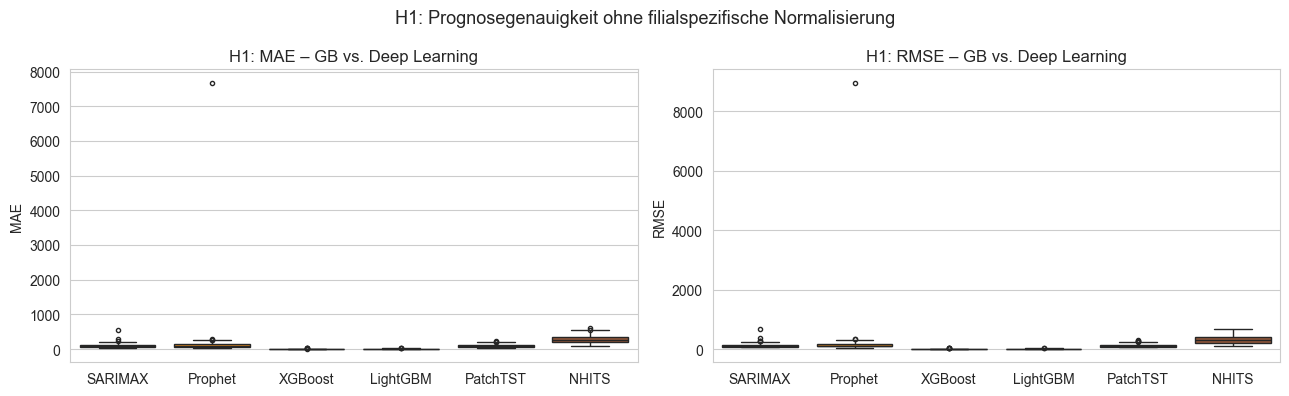

In [ ]:

h1_models_all = ['SARIMAX', 'Prophet','XGBoost', 'LightGBM', 'PatchTST', 'NHITS']
h1_df     = metrics_df[metrics_df['model'].isin(h1_models_all)]
h1_summary = h1_df.groupby('model')[['MAE', 'RMSE']].mean().round(1).sort_values('MAE')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for i, metric in enumerate(['MAE', 'RMSE']):
    sns.boxplot(
        data=h1_df, x='model', y=metric,
        order=h1_models_all,
        palette=MODELL_COLORS,
        flierprops={'markersize': 3}, ax=axes[i]
    )
    axes[i].set_title(f'H1: {metric} – GB vs. Deep Learning', fontsize=12)
    axes[i].set_xlabel('')

plt.suptitle('H1: Prognosegenauigkeit ohne filialspezifische Normalisierung',
             fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
print(h1_summary)

gb_models = ['XGBoost', 'LightGBM']
dl_models = ['PatchTST', 'NHITS']

gb_mae = h1_df[h1_df['model'].isin(gb_models)]['MAE'].mean()
dl_mae = h1_df[h1_df['model'].isin(dl_models)]['MAE'].mean()

print(f'\nØ GB-MAE:          {gb_mae:.1f}')
print(f'Ø DL-MAE:          {dl_mae:.1f}')
print(f'H1 {"BESTÄTIGT ✓" if gb_mae < dl_mae else "WIDERLEGT ✗"}')

            MAE   RMSE
model                 
XGBoost     6.3    8.6
LightGBM    9.5   12.2
PatchTST  101.2  128.9
SARIMAX   106.0  135.9
Prophet   248.4  300.3
NHITS     285.4  316.5

Ø GB-MAE:          7.9
Ø DL-MAE:          193.3
H1 BESTÄTIGT ✓


Wilcoxon Sigifikanztest

Jede GB-Modell-DL-Modell-Paarung wird einzeln getestet, da
unterschiedliche Modellpaare unterschiedlich starke Effekte
zeigen können (z.B. XGBoost vs. NHITS könnte deutlicher ausfallen als XGBoost vs. PatchTST).

In [21]:
from scipy.stats import wilcoxon
import itertools

wilcoxon_results = {}

for gb_model, dl_model in itertools.product(gb_models, dl_models):
    gb_vals = metrics_df[metrics_df['model'] == gb_model].set_index('store_nbr')['MAE']
    dl_vals = metrics_df[metrics_df['model'] == dl_model].set_index('store_nbr')['MAE']
    common  = gb_vals.index.intersection(dl_vals.index)

    stat, p_value = wilcoxon(gb_vals.loc[common], dl_vals.loc[common])
    wilcoxon_results[f'{gb_model} vs. {dl_model}'] = {
        'n': len(common), 'W': stat, 'p': p_value
    }
    sig = 'signifikant' if p_value < 0.05 else 'nicht signifikant'
    print(f'  {gb_model:<10} vs. {dl_model:<10}  '
          f'n={len(common):>2}  W={stat:>7.1f}  p={p_value:.6f}  ({sig})')

  XGBoost    vs. PatchTST    n=53  W=    0.0  p=0.000000  (signifikant)
  XGBoost    vs. NHITS       n=53  W=    0.0  p=0.000000  (signifikant)
  LightGBM   vs. PatchTST    n=53  W=    0.0  p=0.000000  (signifikant)
  LightGBM   vs. NHITS       n=53  W=    0.0  p=0.000000  (signifikant)


### H2: Wenn Feiertagsereignisse im Trainingszeitraum nur selten auftreten, dann weisen featuregetriebene Modelle durch explizite Kalender-Features eine geringere Fehlerquote bei der Feiertagsprognose auf als sequenzbasierte Deep-Learning-Architekturen.
Metrik: MAE separat für Feiertags- und Normaltage.
Relativer Anstieg = (MAE_Feiertag - MAE_Normal) / MAE_Normal * 100
Ein geringerer Anstieg bei GB bestätigt H2.

In [22]:
hol_national = pd.read_parquet(FINAL / 'holiday_features.parquet')
hol_national

,date,is_national_holiday
0,2013-01-02,False
1,2013-01-03,False
2,2013-01-04,False
3,2013-01-05,True
4,2013-01-06,False
...,...,...
1675,2017-08-11,True
1676,2017-08-12,False
1677,2017-08-13,False
1678,2017-08-14,False


In [23]:
base['date'] = base['date'].astype(str)
hol_national['date'] = hol_national['date'].astype(str)
hol_base = base.merge(hol_national, on='date', how='left')
hol_base

,store_nbr,date,y_true,pred_xgb,pred_lgbm,pred_patchtst,pred_nhits,pred_sarimax,pred_prophet,type,cluster,is_national_holiday
0,1,2017-06-01,1815,1816.982300,1809.406816,1660.943970,1671.510742,1602.027703,1685.763841,D,13,False
1,1,2017-06-02,1925,1979.134888,1919.192006,1565.402954,1618.768677,1454.307586,1702.832804,D,13,False
2,1,2017-06-03,1420,1426.523315,1406.175371,1360.430908,1562.789307,1240.680557,1246.257371,D,13,False
3,1,2017-06-04,525,525.163391,532.730107,474.035034,1319.485718,545.854603,459.782668,D,13,False
4,1,2017-06-05,1883,1881.178955,1892.467546,1192.562134,1697.511353,1669.458555,1676.592816,D,13,False
...,...,...,...,...,...,...,...,...,...,...,...,...
4099,54,2017-08-11,768,770.002380,774.441403,843.519897,1286.097900,771.595969,754.592989,C,3,True
4100,54,2017-08-12,903,896.292053,901.082840,868.788513,1402.123169,946.317499,932.948913,C,3,False
4101,54,2017-08-13,1054,1054.234619,1053.828172,1003.213318,1400.005615,1084.098506,1100.898020,C,3,False
4102,54,2017-08-14,818,819.478394,817.904740,946.838257,1308.153076,822.844112,822.234089,C,3,False


In [25]:
hol_records = []
h2_models = ['SARIMAX', 'Prophet','XGBoost', 'LightGBM', 'PatchTST', 'NHITS']

for model_name, col in {m: models_cfg[m] for m in h2_models}.items():
    if col not in hol_base.columns:
        continue
    for is_hol, grp in hol_base.groupby('is_national_holiday'):
        mask   = grp[col].notna() & grp['y_true'].notna()
        y_true = grp.loc[mask, 'y_true'].values
        y_pred = grp.loc[mask, col].values
        if len(y_true) == 0:
            continue
        hol_records.append({
            'model':      model_name,
            'is_national_holiday': 'Feiertag' if is_hol else 'Normal',
            'MAE':        mean_absolute_error(y_true, y_pred),
            'n':          len(y_true),
        })

hol_metrics = pd.DataFrame(hol_records)
hol_metrics

,model,is_national_holiday,MAE,n
0,SARIMAX,Normal,105.119758,4050
1,SARIMAX,Feiertag,169.059706,54
2,Prophet,Normal,245.228769,4050
3,Prophet,Feiertag,485.667297,54
4,XGBoost,Normal,6.257629,4050
5,XGBoost,Feiertag,7.064027,54
6,LightGBM,Normal,9.425879,4050
7,LightGBM,Feiertag,12.737129,54
8,PatchTST,Normal,99.917168,3975
9,PatchTST,Feiertag,196.756870,53


In [27]:
pivot = hol_metrics.pivot(index='model', columns='is_national_holiday', values='MAE')
pivot['Anstieg (%)'] = (
    (pivot['Feiertag'] - pivot['Normal']) / pivot['Normal'] * 100
).round(1)
pivot

is_national_holiday,Feiertag,Normal,Anstieg (%)
model,,,
LightGBM,12.737129,9.425879,35.1
NHITS,441.928134,283.339665,56.0
PatchTST,196.756870,99.917168,96.9
Prophet,485.667297,245.228769,98.0
SARIMAX,169.059706,105.119758,60.8
XGBoost,7.064027,6.257629,12.9


C:\Users\maxkr\AppData\Local\Temp\ipykernel_21472\3645444036.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


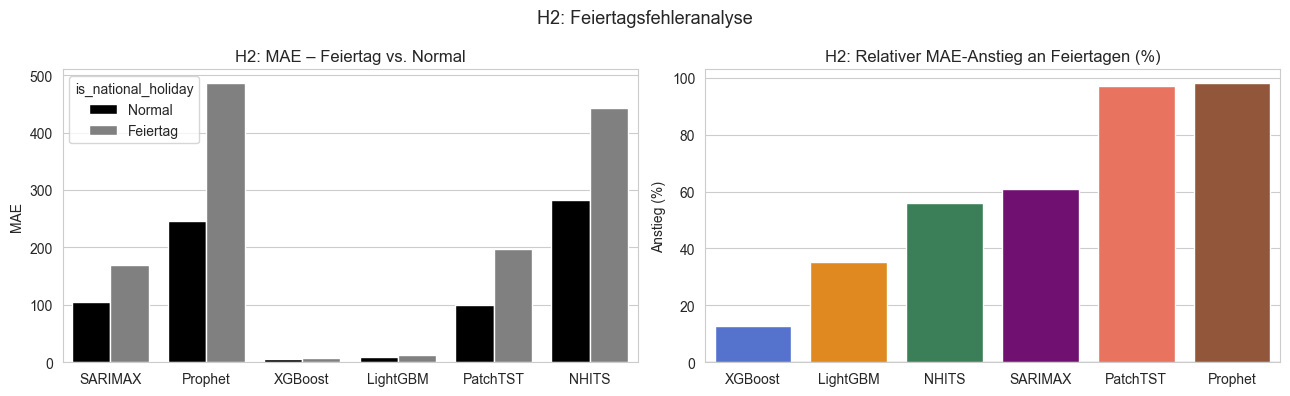

In [32]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(
    data=hol_metrics, x='model', y='MAE',
    hue='is_national_holiday', hue_order=['Normal', 'Feiertag'],
    palette={'Normal': 'black', 'Feiertag': 'grey'},
    ax=axes[0]
)
axes[0].set_title('H2: MAE – Feiertag vs. Normal', fontsize=12)
axes[0].set_xlabel('')

sns.barplot(
    data=pivot.reset_index().sort_values(by="Anstieg (%)", ascending=True), x='model', y='Anstieg (%)',
    palette=[MODELL_COLORS[m] for m in h2_models], ax=axes[1]
)
axes[1].set_title('H2: Relativer MAE-Anstieg an Feiertagen (%)', fontsize=12)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('')

plt.suptitle('H2: Feiertagsfehleranalyse', fontsize=13)
plt.tight_layout()
plt.show()


### H3: Wenn stark autokorrelierte Zeitreihenabschnitte vorliegen, dann bildet die Deep-Learning-Architekturen die Dynamiken ohne explizites Feature Engineering ebenso präzise oder präziser ab als Gradient-Boosting-Verfahren.

Metrik: MAPE (skalierungsunabhängig für Filialvergleiche)
Schwellenwert ACF > 0.7: überdurchschnittlich stark autokorreliert
(Median über alle Stores: ~0.63)
Bestätigt wenn: DL-MAPE ≤ GB-MAPE bei diesen Stores

In [33]:

high_acf  = metrics_df[metrics_df['acf_lag7'] > 0.7]
h3_models =['SARIMAX', 'Prophet','XGBoost', 'LightGBM', 'PatchTST', 'NHITS']
h3_df     = high_acf[high_acf['model'].isin(h3_models)]
n_stores_high = high_acf['store_nbr'].nunique()
h3_summary = h3_df.groupby('model')['MAPE'].mean().round(2).sort_values()
h3_summary

model
XGBoost      0.33
LightGBM     0.54
SARIMAX      6.44
PatchTST     6.56
Prophet     17.39
NHITS       20.26
Name: MAPE, dtype: float64

C:\Users\maxkr\AppData\Local\Temp\ipykernel_21472\744663037.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


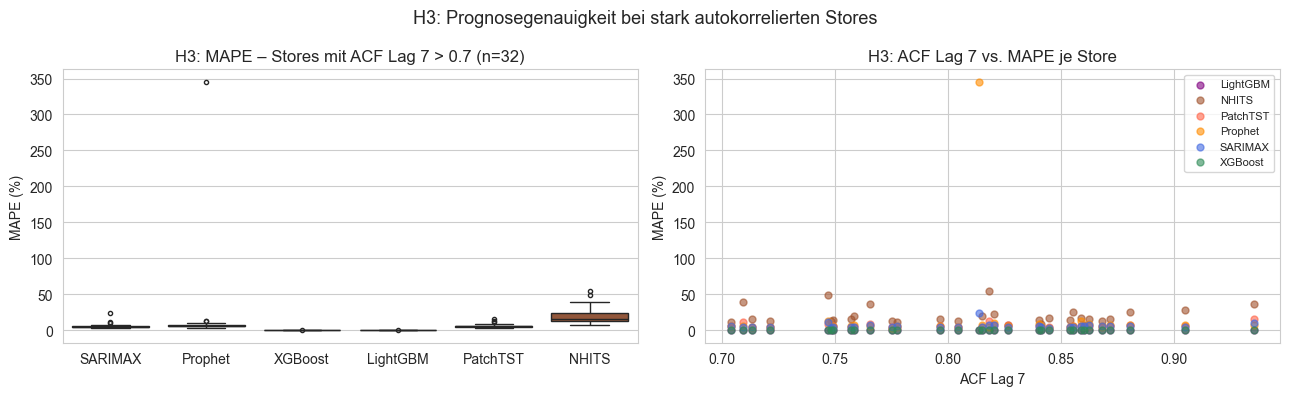

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(
    data=h3_df, x='model', y='MAPE',
    order=h3_models,
    palette=[MODELL_COLORS[m] for m in h3_models],
    flierprops={'markersize': 3}, ax=axes[0]
)
axes[0].set_title(f'H3: MAPE – Stores mit ACF Lag 7 > 0.7 (n={n_stores_high})',
                  fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('MAPE (%)')

for model_name, grp in h3_df.groupby('model'):
    axes[1].scatter(
        grp['acf_lag7'], grp['MAPE'],
        label=model_name, alpha=0.6, s=25,
        color=MODELL_COLORS[model_name]
    )
axes[1].set_title('H3: ACF Lag 7 vs. MAPE je Store', fontsize=12)
axes[1].set_xlabel('ACF Lag 7')
axes[1].set_ylabel('MAPE (%)')
axes[1].legend(fontsize=8)

plt.suptitle('H3: Prognosegenauigkeit bei stark autokorrelierten Stores',
             fontsize=13)
plt.tight_layout()
plt.show()

C:\Users\maxkr\AppData\Local\Temp\ipykernel_21472\1095149743.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


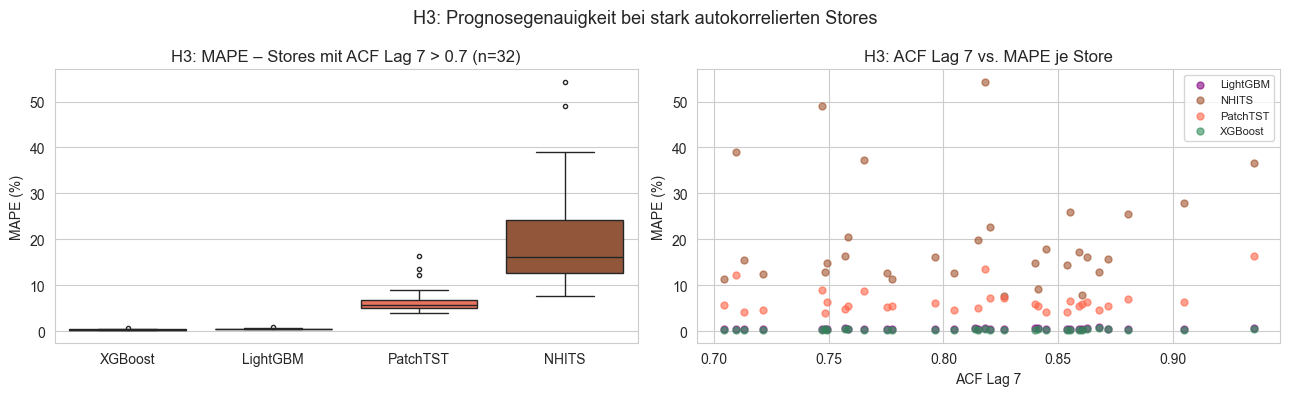

In [36]:

high_acf  = metrics_df[metrics_df['acf_lag7'] > 0.7]
h3_models =['XGBoost', 'LightGBM', 'PatchTST', 'NHITS']
h3_df     = high_acf[high_acf['model'].isin(h3_models)]
n_stores_high = high_acf['store_nbr'].nunique()
h3_summary = h3_df.groupby('model')['MAPE'].mean().round(2).sort_values()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(
    data=h3_df, x='model', y='MAPE',
    order=h3_models,
    palette=[MODELL_COLORS[m] for m in h3_models],
    flierprops={'markersize': 3}, ax=axes[0]
)
axes[0].set_title(f'H3: MAPE – Stores mit ACF Lag 7 > 0.7 (n={n_stores_high})',
                  fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('MAPE (%)')

for model_name, grp in h3_df.groupby('model'):
    axes[1].scatter(
        grp['acf_lag7'], grp['MAPE'],
        label=model_name, alpha=0.6, s=25,
        color=MODELL_COLORS[model_name]
    )
axes[1].set_title('H3: ACF Lag 7 vs. MAPE je Store', fontsize=12)
axes[1].set_xlabel('ACF Lag 7')
axes[1].set_ylabel('MAPE (%)')
axes[1].legend(fontsize=8)

plt.suptitle('H3: Prognosegenauigkeit bei stark autokorrelierten Stores',
             fontsize=13)
plt.tight_layout()
plt.show()

C:\Users\maxkr\AppData\Local\Temp\ipykernel_21472\3170160530.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


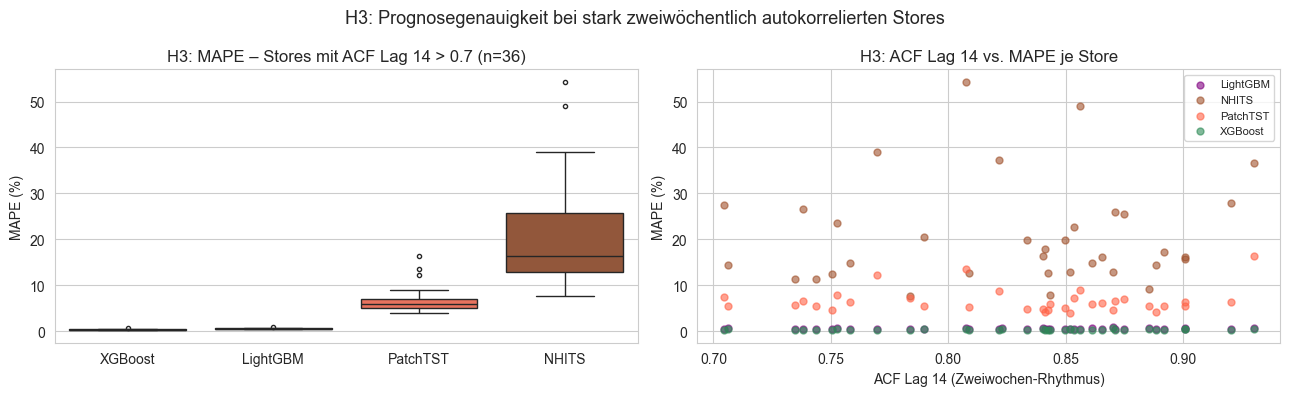

In [ ]:
high_acf_14  = metrics_df[metrics_df['acf_lag14'] > 0.7] 
h3_models_14 = ['XGBoost', 'LightGBM', 'PatchTST', 'NHITS']
h3_df_14     = high_acf_14[high_acf_14['model'].isin(h3_models_14)]
n_stores_high_14 = high_acf_14['store_nbr'].nunique()


fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(
    data=h3_df_14, x='model', y='MAPE',
    order=h3_models_14,
    palette=[MODELL_COLORS[m] for m in h3_models_14],
    flierprops={'markersize': 3}, ax=axes[0]
)
axes[0].set_title(f'H3: MAPE – Stores mit ACF Lag 14 > 0.7 (n={n_stores_high_14})', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('MAPE (%)')

for model_name, grp in h3_df_14.groupby('model'):
    axes[1].scatter(
        grp['acf_lag14'], grp['MAPE'],
        label=model_name, alpha=0.6, s=25,
        color=MODELL_COLORS[model_name]
    )
axes[1].set_title('H3: ACF Lag 14 vs. MAPE je Store', fontsize=12)
axes[1].set_xlabel('ACF Lag 14 (Zweiwochen-Rhythmus)')
axes[1].set_ylabel('MAPE (%)')
axes[1].legend(fontsize=8)

plt.suptitle('H3: Prognosegenauigkeit bei stark zweiwöchentlich autokorrelierten Stores', fontsize=13)
plt.tight_layout()
plt.show()

## H4: Wenn exogene Faktoren ohne relevante lineare oder nicht-lineare Korrelationen integriert werden, dann führt dies unabhängig von der Modellarchitektur zu keiner signifikanten Verbesserung der Prognosegüte.

Direkter Vergleich: NHITS (mit Exogenen) vs. PatchTST (ohne). Bei GB sind Exogene als Features kodiert → als Referenz mitgezeigt.
Metrik: MAE und MAPE. Bestätigt wenn: NHITS kein konsistenter Vorteil vs. PatchTST

In [20]:
h4_dl_models = ['PatchTST', 'NHITS']
h4_dl_df     = metrics_df[metrics_df['model'].isin(h4_dl_models)]
pt_mae  = metrics_df[metrics_df['model'] == 'PatchTST']\
            .set_index('store_nbr')['MAE']
nhi_mae = metrics_df[metrics_df['model'] == 'NHITS']\
            .set_index('store_nbr')['MAE']
diff = (nhi_mae - pt_mae).rename('MAE-Differenz (NHITS − PatchTST)')


C:\Users\maxkr\AppData\Local\Temp\ipykernel_25232\1765607427.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


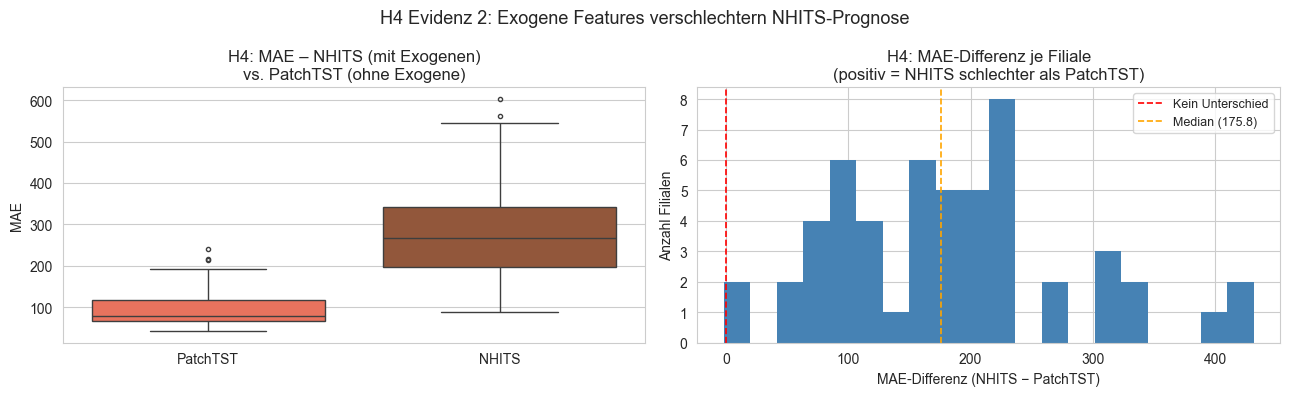

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(
    data=h4_dl_df, x='model', y='MAE',
    order=h4_dl_models,
    palette=[MODELL_COLORS[m] for m in h4_dl_models],
    flierprops={'markersize': 3}, ax=axes[0]
)
axes[0].set_title('H4: MAE – NHITS (mit Exogenen)\nvs. PatchTST (ohne Exogene)',
                  fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('MAE')

# Histogramm: MAE-Differenz je Filiale
axes[1].hist(diff.dropna(), bins=20, color='steelblue', edgecolor='none')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.2,
                label='Kein Unterschied')
axes[1].axvline(diff.median(), color='orange', linestyle='--',
                linewidth=1.2,
                label=f'Median ({diff.median():.1f})')
axes[1].set_title('H4: MAE-Differenz je Filiale\n'
                  '(positiv = NHITS schlechter als PatchTST)',
                  fontsize=12)
axes[1].set_xlabel('MAE-Differenz (NHITS − PatchTST)')
axes[1].set_ylabel('Anzahl Filialen')
axes[1].legend(fontsize=9)

plt.suptitle('H4 Evidenz 2: Exogene Features verschlechtern NHITS-Prognose',
             fontsize=13)
plt.tight_layout()
plt.show()

  oil_price                           r = -0.079
  is_national_holiday                 r = +0.094
  is_day_before_holiday               r = +0.030
  is_day_after_holiday                r = +0.164


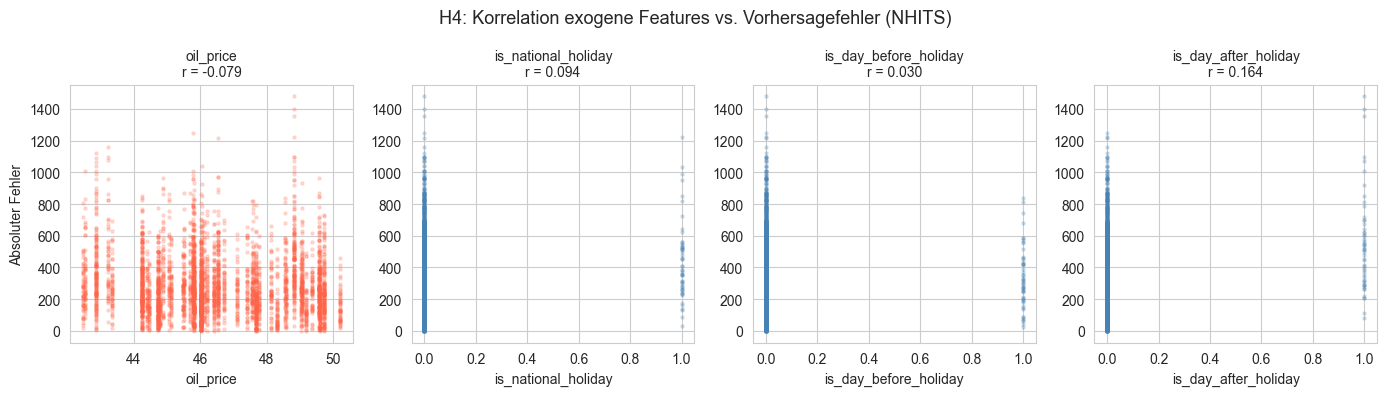

In [42]:
nhits_preds = pl.read_parquet(RESULTS / 'test_nhits.parquet').to_pandas()
nhits_preds['error'] = np.abs(
    nhits_preds['y_true'] - nhits_preds['pred_nhits']
)

test_pd = test.select(['store_nbr', 'date'] + HIST_EXOG).to_pandas()
nhits_err = nhits_preds.merge(test_pd, on=['store_nbr', 'date'], how='left')

corr_results = {}
for feat in HIST_EXOG:
    r = nhits_err[feat].corr(nhits_err['error'])
    corr_results[feat] = r
    print(f'  {feat:<35} r = {r:+.3f}')

fig, axes = plt.subplots(1, len(HIST_EXOG), figsize=(14, 4))
for i, feat in enumerate(HIST_EXOG):
    color = 'tomato' if 'oil' in feat else 'steelblue'
    axes[i].scatter(nhits_err[feat], nhits_err['error'],
                    alpha=0.2, s=5, color=color)
    axes[i].set_title(f'{feat}\nr = {corr_results[feat]:.3f}', fontsize=10)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Absoluter Fehler' if i == 0 else '')

plt.suptitle('H4: Korrelation exogene Features vs. Vorhersagefehler (NHITS)',
             fontsize=13)
plt.tight_layout()
plt.show()

── Feature Importance: Ölpreis-Rang ──
  XGBoost – oil_price: Rang 27 von 33 (Importance: 0.0000)
  XGBoost – oil_price_ma7: Rang 29 von 33 (Importance: 0.0000)
  LightGBM – oil_price: Rang 19 von 33 (Importance: 129.0000)
  LightGBM – oil_price_ma7: Rang 18 von 33 (Importance: 134.0000)


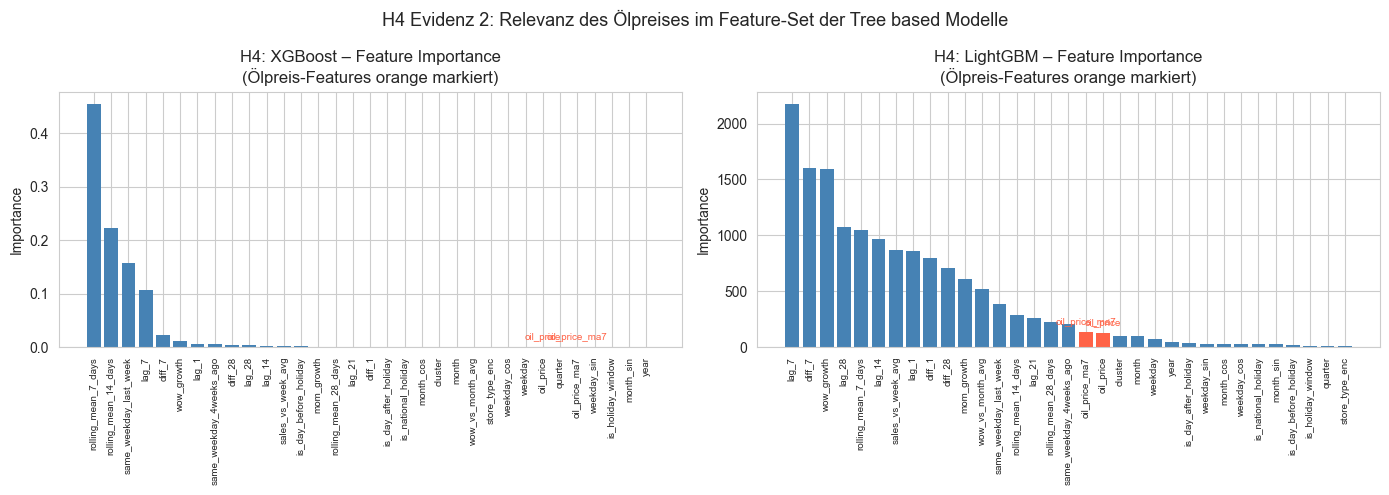

In [39]:
model_xgb  = joblib.load(RESULTS / 'model_xgb_final.pkl')
model_lgbm = joblib.load(RESULTS / 'model_lgbm_final.pkl')

fi_xgb  = pd.Series(model_xgb.feature_importances_,
                     index=FEATURE_COLS).sort_values(ascending=False)
fi_lgbm = pd.Series(model_lgbm.feature_importances_,
                     index=FEATURE_COLS).sort_values(ascending=False)

oil_features = ['oil_price', 'oil_price_ma7']

print('── Feature Importance: Ölpreis-Rang ──')
for name, fi in [('XGBoost', fi_xgb), ('LightGBM', fi_lgbm)]:
    for feat in oil_features:
        rang = fi.index.get_loc(feat) + 1
        print(f'  {name} – {feat}: Rang {rang} von {len(fi)} '
              f'(Importance: {fi[feat]:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (name, fi) in enumerate([('XGBoost', fi_xgb),
                                  ('LightGBM', fi_lgbm)]):
    colors_fi = ['tomato' if f in oil_features else 'steelblue'
                 for f in fi.index]
    axes[i].bar(range(len(fi)), fi.values,
                color=colors_fi, edgecolor='none')
    axes[i].set_xticks(range(len(fi)))
    axes[i].set_xticklabels(fi.index, rotation=90, fontsize=7)
    axes[i].set_title(f'H4: {name} – Feature Importance\n'
                      f'(Ölpreis-Features orange markiert)', fontsize=12)
    axes[i].set_ylabel('Importance')

    for feat in oil_features:
        if feat in fi.index:
            idx = fi.index.get_loc(feat)
            axes[i].annotate(feat, (idx, fi[feat]),
                             textcoords='offset points',
                             xytext=(0, 5), fontsize=7,
                             color='tomato', ha='center')

plt.suptitle('H4 Evidenz 2: Relevanz des Ölpreises im Feature-Set der Tree based Modelle',
             fontsize=13)
plt.tight_layout()
plt.show()

## H5: Wenn hochfrequente Einzelhandelsdaten verarbeitet werden, bieten Gradient-Boosting-Verfahren einen signifikanten Effizienzvorteil (Rechenzeit) gegenüber Deep-Learning-Architekturen ohne relevanten Verlust an Prognosegenauigkeit

Trainingszeiten stammen aus NB04 (Val-Set Training, gleiche Datenbasis) und wurden in training_times.json weggeschrieben.
MAE aus Test-Split (metrics_df) für Effizienz-Frontier Plot. Bestätigt wenn: GB links-unten im Frontier (kurz + genau)

In [48]:
time_df = pd.read_parquet(RESULTS / 'testszeit.parquet')
mae_summary = ( metrics_df.groupby('model')['MAE']
    .mean()
    .round(1)
    .reset_index()
    .rename(columns={'model': 'Modell'})
)
effizienz_df  = mae_summary.merge(time_df, how='left', on='Modell')

effizienz_df 

,Modell,MAE,Zeit_Sekunden
0,LightGBM,9.5,2.3
1,NHITS,285.4,81.4
2,PatchTST,101.2,1380.4
3,Prophet,248.4,20.9
4,SARIMAX,106.0,293.4
5,XGBoost,6.3,9.2


In [49]:
effizienz_df = effizienz_df.rename(columns={'Zeit_Sekunden': 'Trainingszeit (s)'})
effizienz_df['Trainingszeit (min)'] = (effizienz_df['Trainingszeit (s)'] / 60).round(1)

print(effizienz_df.sort_values('Trainingszeit (s)'))

     Modell    MAE  Trainingszeit (s)  Trainingszeit (min)
0  LightGBM    9.5                2.3                  0.0
5   XGBoost    6.3                9.2                  0.2
3   Prophet  248.4               20.9                  0.3
1     NHITS  285.4               81.4                  1.4
4   SARIMAX  106.0              293.4                  4.9
2  PatchTST  101.2             1380.4                 23.0


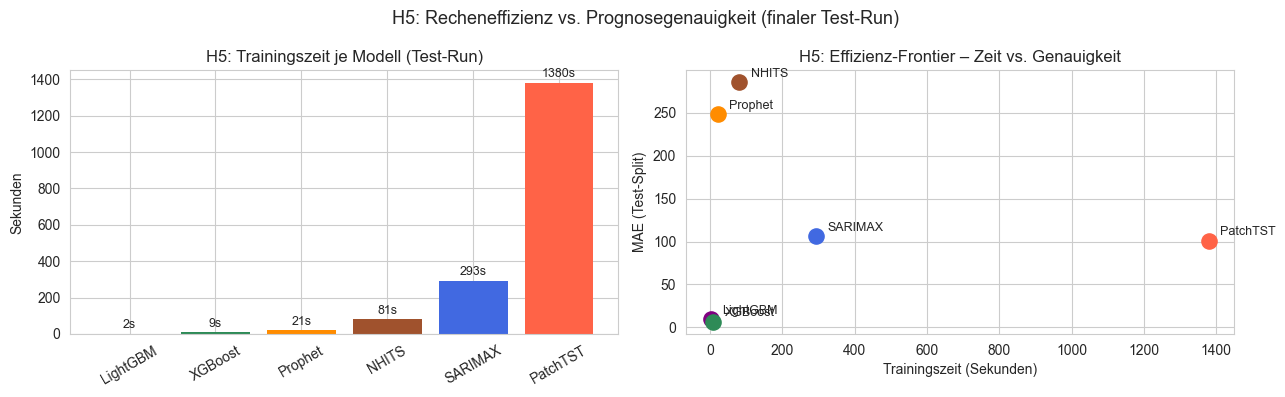

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

order = effizienz_df.sort_values('Trainingszeit (s)')['Modell'].tolist()
colors_h5 = [MODELL_COLORS.get(m, 'gray') for m in order]

bars = axes[0].bar(
    order,
    effizienz_df.set_index('Modell').loc[order, 'Trainingszeit (s)'],
    color=colors_h5, edgecolor='none'
)
for bar, val in zip(bars, effizienz_df.set_index('Modell').loc[order, 'Trainingszeit (s)']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + effizienz_df['Trainingszeit (s)'].max()*0.01,
                 f'{val:.0f}s', ha='center', va='bottom', fontsize=9)
axes[0].set_title('H5: Trainingszeit je Modell (Test-Run)', fontsize=12)
axes[0].set_ylabel('Sekunden')
axes[0].tick_params(axis='x', rotation=30)

for _, row in effizienz_df.iterrows():
    axes[1].scatter(row['Trainingszeit (s)'], row['MAE'],
                    color=MODELL_COLORS.get(row['Modell'], 'gray'),
                    s=120, zorder=5)
    axes[1].annotate(row['Modell'],
                     (row['Trainingszeit (s)'], row['MAE']),
                     textcoords='offset points', xytext=(8, 4), fontsize=9)
axes[1].set_xlabel('Trainingszeit (Sekunden)')
axes[1].set_ylabel('MAE (Test-Split)')
axes[1].set_title('H5: Effizienz-Frontier – Zeit vs. Genauigkeit', fontsize=12)

plt.suptitle('H5: Recheneffizienz vs. Prognosegenauigkeit (finaler Test-Run)', fontsize=13)
plt.tight_layout()
plt.show()

## H6: Wenn eine globale Modellierung aller Filialen erfolgt, dann weisen Deep-Learning-Architekturen bei Filialen mit hoher Varianz eine höhere Generalisierungsfähigkeit und geringere Out-of-Sample-Fehler auf als baumbasierte Verfahren.

Metrik: MAE (absolut) und MAPE (relativ/skalierungsunabhängig). Zusätzlich: Korrelation Filialvarianz vs. MAPE je Modell. Bestätigt wenn: DL höhere MAPE bei Typ A als GB

In [ ]:
h6_models  = ['XGBoost', 'LightGBM', 'PatchTST', 'NHITS']
h6_df      = metrics_df[metrics_df['model'].isin(h6_models)]
type_order = [t for t in ['A', 'B', 'C', 'D', 'E']
              if t in h6_df['store_type'].unique()]

h6_summary = h6_df.groupby(['model', 'store_type'])[['MAE', 'MAPE']].mean().round(2)
typeA = h6_df[h6_df['store_type'] == 'A']
gb_mape_A  = typeA[typeA['model'].isin(['XGBoost','LightGBM'])]['MAPE'].mean()
dl_mape_A  = typeA[typeA['model'].isin(['PatchTST','NHITS'])]['MAPE'].mean()

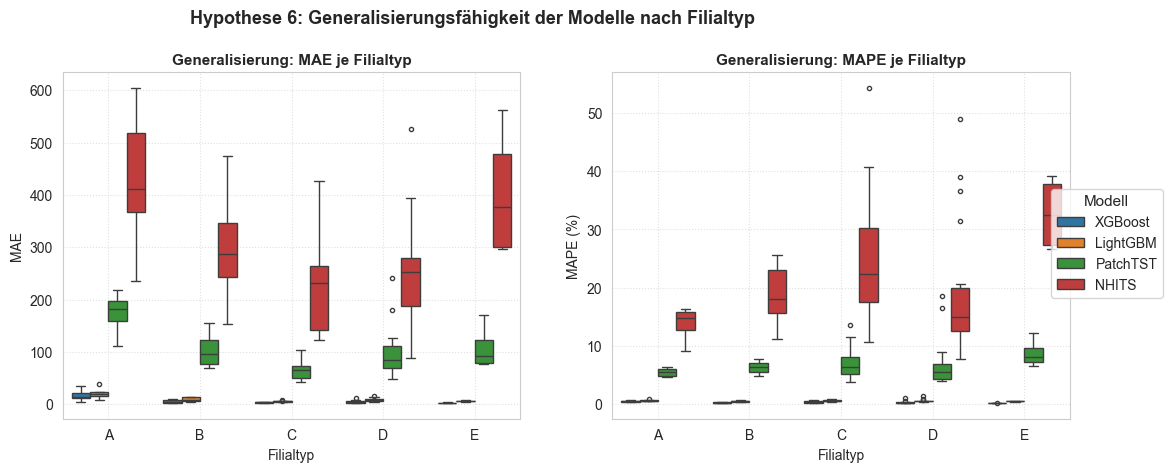

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for i, metric in enumerate(['MAE', 'MAPE']):
    sns.boxplot(
        data=h6_df, x='store_type', y=metric,
        hue='model', hue_order=h6_models,
        order=type_order,
        flierprops={'markersize': 3}, ax=axes[i]
    )
    axes[i].set_title(f'Generalisierung: {metric} je Filialtyp', fontsize=11, weight='bold')
    axes[i].set_xlabel('Filialtyp')
    axes[i].grid(True, linestyle=':', alpha=0.6)

axes[0].set_ylabel('MAE')
axes[1].set_ylabel('MAPE (%)')


handles, labels = axes[0].get_legend_handles_labels()

axes[0].get_legend().remove()
axes[1].get_legend().remove()

fig.legend(
    handles, labels, 
    title='Modell', 
    loc='center left', 
    bbox_to_anchor=(0.88, 0.5),
    fontsize=10,
    title_fontsize=11
)

plt.suptitle('Hypothese 6: Generalisierungsfähigkeit der Modelle nach Filialtyp', 
             fontsize=13, weight='bold', y=1.02, x=0.44)


plt.show()